# Week 8 · Day 2 — A Neuron From Scratch

Yesterday was theory. Today we build. And here's the reassuring secret: **a single neuron is logistic regression** — so the code we write today is code you already know from Week 6. Nothing new to fear.

We'll build one neuron, train it with gradient descent (the same loop you've run since Week 5), and then hit a wall: one neuron **can't solve XOR**. That wall is exactly why we need *networks* — and it sets up tomorrow.

<img src="images/single_neuron.jpg">

**The plan:**
1. Build a neuron (inputs → weights → bias → activation → output).
2. Train it with gradient descent — watch the loss fall.
3. Activation functions in code: sigmoid and ReLU.
4. The limit: one neuron fails at XOR.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---
## 1. Build a neuron

A neuron does three things: takes inputs, computes a **weighted sum plus bias** (`w·x + b`), and passes that through an **activation** (sigmoid). That's it — and it's exactly the logistic regression model from Week 6.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def neuron(x, w, b):
    z = np.dot(w, x) + b     # weighted sum + bias
    return sigmoid(z)        # activation

Let's run one neuron by hand with made-up weights, on a single input.

In [3]:
x = np.array([0.8, 0.9])     # one example with 2 features
w = np.array([1.5, 2.0])     # weights (one per feature)
b = -1.0                     # bias

output = neuron(x, w, b)
print(f"the neuron's output: {output:.3f}")
print("it's between 0 and 1 — a probability, exactly like logistic regression.")

the neuron's output: 0.881
it's between 0 and 1 — a probability, exactly like logistic regression.


---
## 2. Train the neuron with gradient descent

Made-up weights are useless — we need to *learn* good ones from data. The training loop is the **same four moves** you've done since Week 5: predict → measure loss → compute gradients → update.

Our data: a simple, **linearly separable** problem. Class 0 = both inputs low, class 1 = both inputs high.

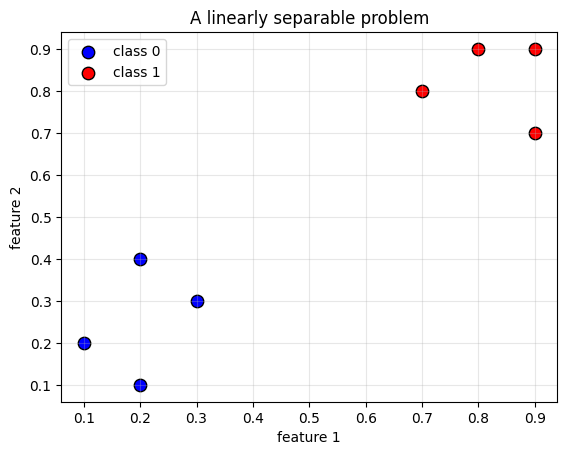

In [4]:
# 8 examples, 2 features each
X = np.array([[0.1,0.2],[0.2,0.1],[0.3,0.3],[0.2,0.4],    # class 0 (low values)
              [0.8,0.9],[0.9,0.7],[0.7,0.8],[0.9,0.9]])    # class 1 (high values)
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

plt.scatter(X[y==0,0], X[y==0,1], c="blue", s=80, edgecolor="k", label="class 0")
plt.scatter(X[y==1,0], X[y==1,1], c="red", s=80, edgecolor="k", label="class 1")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.legend()
plt.title("A linearly separable problem"); plt.grid(alpha=0.3)
plt.show()

The two classes are cleanly separated — a single straight boundary can split them. Perfect for one neuron. Now the training loop.

In [5]:
# functions that work on ALL examples at once (vectorized)
def predict(X, w, b):
    return sigmoid(X @ w + b)          # X @ w does every example at once

def loss(X, y, w, b):
    p = predict(X, w, b)
    return -np.mean(y*np.log(p+1e-9) + (1-y)*np.log(1-p+1e-9))   # log loss

In [6]:
# start with zero weights, then run gradient descent
w = np.zeros(2)
b = 0.0
learning_rate = 1.0
history = []

for epoch in range(500):
    p = predict(X, w, b)               # 1. predict
    history.append(loss(X, y, w, b))   #    (record the loss)
    error = p - y                      # 2. how wrong
    grad_w = X.T @ error / len(y)      # 3. gradients
    grad_b = np.mean(error)
    w = w - learning_rate * grad_w     # 4. update
    b = b - learning_rate * grad_b

print(f"final loss: {history[-1]:.4f}")
print(f"learned weights: {w.round(2)},  bias: {b:.2f}")

final loss: 0.0239
learned weights: [7.47 6.1 ],  bias: -7.00


Watch the loss fall — the picture of a neuron learning, identical to every model you've trained.

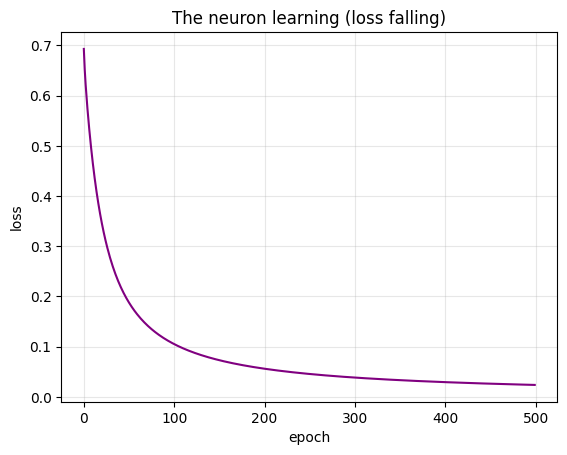

In [7]:
plt.plot(history, color="purple")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("The neuron learning (loss falling)")
plt.grid(alpha=0.3)
plt.show()

In [8]:
# did it work? check predictions vs actual
predictions = (predict(X, w, b) > 0.5).astype(int)
accuracy = np.mean(predictions == y)
print(f"predictions: {predictions}")
print(f"actual:      {y}")
print(f"accuracy: {accuracy:.0%}")

predictions: [0 0 0 0 1 1 1 1]
actual:      [0 0 0 0 1 1 1 1]
accuracy: 100%


**100% accuracy** — a "neural network" of one neuron, trained entirely by hand, with zero new concepts. It *is* logistic regression; we're just calling it a neuron now.

---
## 3. Activation functions

The activation is what makes a neuron more than a plain line. We used **sigmoid**; the other one you met on the slides is **ReLU** — the modern default. Let's implement and see both.

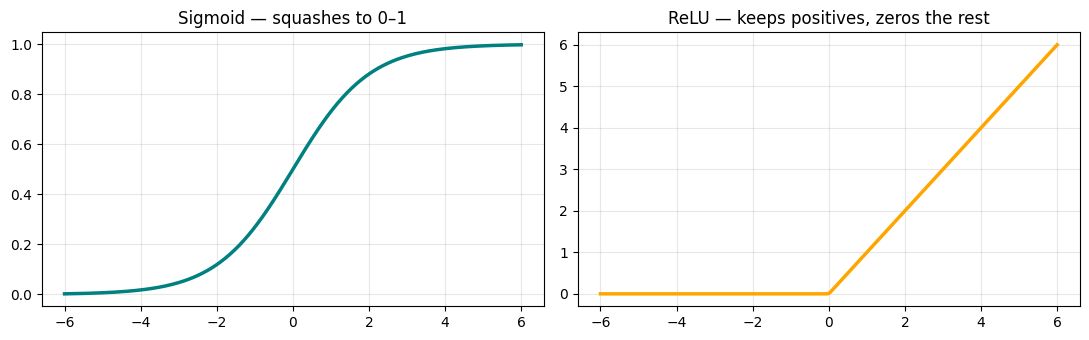

In [9]:
def relu(z):
    return np.maximum(0, z)     # keep positives, zero out negatives

z = np.linspace(-6, 6, 200)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(z, sigmoid(z), color="teal", linewidth=2.5)
ax[0].set_title("Sigmoid — squashes to 0–1"); ax[0].grid(alpha=0.3)
ax[1].plot(z, relu(z), color="orange", linewidth=2.5)
ax[1].set_title("ReLU — keeps positives, zeros the rest"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# feel how each behaves on a few numbers
for val in [-5, -1, 0, 1, 5]:
    print(f"input {val:3d}  →  sigmoid {sigmoid(val):.3f}   relu {relu(val):.1f}")

input  -5  →  sigmoid 0.007   relu 0.0
input  -1  →  sigmoid 0.269   relu 0.0
input   0  →  sigmoid 0.500   relu 0.0
input   1  →  sigmoid 0.731   relu 1.0
input   5  →  sigmoid 0.993   relu 5.0


Sigmoid gently squashes everything into 0–1 (good for probabilities at the output). ReLU is brutally simple — negatives become 0, positives pass through — which makes it fast and effective *inside* a network's hidden layers. You'll use both tomorrow.

---
## 4. The limit of one neuron: XOR

One neuron draws **one straight line**. That's enough for our separable data — but some problems can't be split by any straight line. The classic example is **XOR**:

| input 1 | input 2 | output |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | 0 |

The output is 1 when the inputs *differ*. Let's plot it and see the problem.

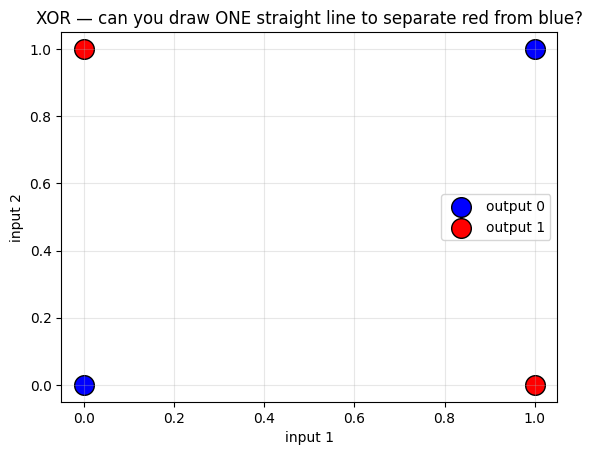

In [11]:
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

plt.scatter(X_xor[y_xor==0,0], X_xor[y_xor==0,1], c="blue", s=200, edgecolor="k", label="output 0")
plt.scatter(X_xor[y_xor==1,0], X_xor[y_xor==1,1], c="red", s=200, edgecolor="k", label="output 1")
plt.xlabel("input 1"); plt.ylabel("input 2"); plt.legend()
plt.title("XOR — can you draw ONE straight line to separate red from blue?")
plt.grid(alpha=0.3); plt.show()

Try it with your eyes: **there is no single straight line** that puts both red dots on one side and both blue dots on the other. They're diagonal from each other. A single neuron — which can only draw one line — is doomed here. Let's prove it by training one.

In [12]:
# train a single neuron on XOR — as hard as we can
w = np.zeros(2)
b = 0.0
for epoch in range(5000):
    p = predict(X_xor, w, b)
    error = p - y_xor
    w = w - 0.5 * (X_xor.T @ error / 4)
    b = b - 0.5 * np.mean(error)

predictions = (predict(X_xor, w, b) > 0.5).astype(int)
print(f"predictions: {predictions}")
print(f"actual:      {y_xor}")
print(f"accuracy: {np.mean(predictions == y_xor):.0%}")

predictions: [0 0 0 0]
actual:      [0 1 1 0]
accuracy: 50%


**Stuck at 50%** — no better than guessing. Even trained for 5000 epochs, the single neuron *cannot* solve XOR. It's not a bug or a bad learning rate; it's a fundamental limit: **one neuron draws one line, and one line can't separate XOR.**

This exact failure caused a real "AI Winter" in the 1970s — people thought neural networks were a dead end. The way out, discovered later, is simple to state:

> **Stack neurons into layers. A network of neurons can draw curved, complex boundaries that a single neuron never could.**

That's tomorrow. We'll build a small multi-layer network, learn **backpropagation** to train it, and watch it *solve the XOR that defeated us today.*

---
## Summary

- A **neuron** = weighted sum + bias, through an **activation**: `output = sigmoid(w·x + b)`. This *is* logistic regression.
- It **trains with gradient descent** — the same predict → loss → gradients → update loop you've used all course. It reached 100% on a linearly-separable problem.
- **Sigmoid** squashes to 0–1 (good at the output); **ReLU** keeps positives and zeros negatives (fast, used in hidden layers).
- A single neuron draws **one straight line**, so it **cannot solve XOR** — a problem needing a non-linear boundary. It got stuck at 50%.
- The fix is to **stack neurons into layers** — a real neural network. That's Day 3.

You built and trained a neuron from scratch, and found exactly why one isn't enough. Tomorrow, we make it a network.